In [1]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("../data/mattakelle_dataset.csv")

# remove duplicates
df = df.drop_duplicates().copy()

# remove unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")].copy()

# drop raw date columns if they exist
date_cols_to_drop = [
    "month_date",
    "dolomite_applied_date",
    "last_fertilized_date",
    "last_weeding_date",
    "weeded_until_date"
]
existing_date_cols = [col for col in date_cols_to_drop if col in df.columns]
df = df.drop(columns=existing_date_cols)

# target
target_column = "yph_target"

X = df.drop(columns=[target_column]).copy()
y = df[target_column].copy()

# identify types
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

# fill missing values
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# one-hot encoding for general use
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# clean column names
X_encoded.columns = X_encoded.columns.str.replace(" ", "_")

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training R²")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation R²")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("R² Score")
    plt.legend()
    plt.grid(True)
    plt.show()

## Linear Regression learning curve

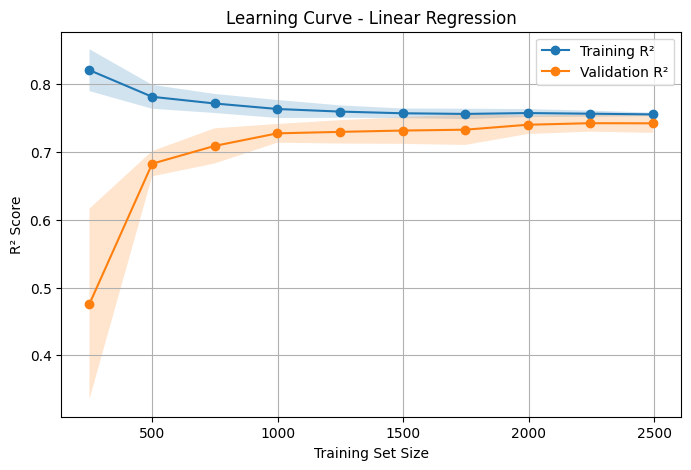

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

plot_learning_curve(lr_model, X_encoded, y, "Learning Curve - Linear Regression")

## XGBoost learning curve

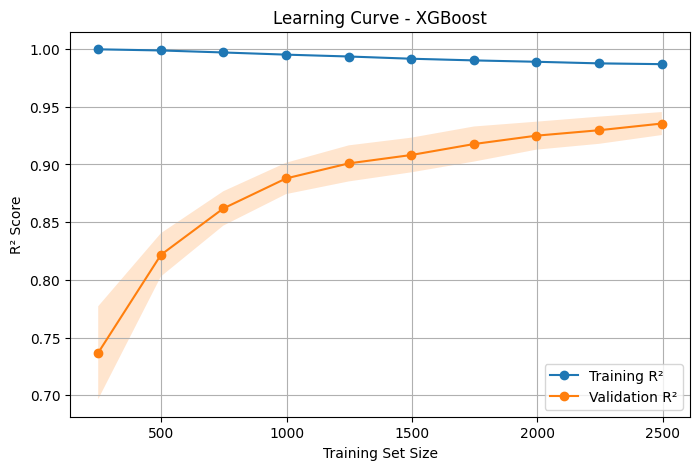

In [5]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

plot_learning_curve(xgb_model, X_encoded, y, "Learning Curve - XGBoost")

## LightGBM learning curve

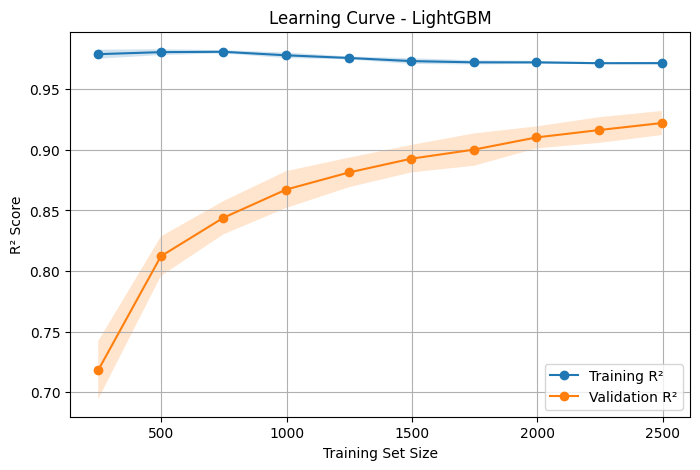

In [6]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=-1
)

plot_learning_curve(lgb_model, X_encoded, y, "Learning Curve - LightGBM")

## CatBoost learning curve

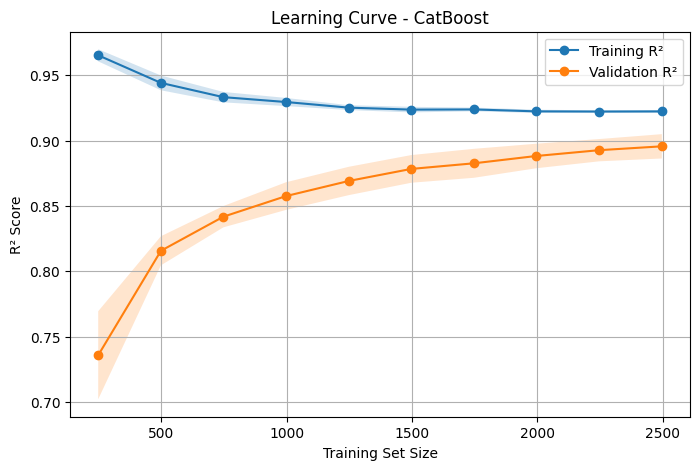

In [7]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

plot_learning_curve(cat_model, X_encoded, y, "Learning Curve - CatBoost")

## LSTM learning curve

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# load dataset
df = pd.read_csv("../data/mattakelle_dataset.csv")

# clean
df = df.drop_duplicates()
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# sort by time
if "month_date" in df.columns:
    df["month_date"] = pd.to_datetime(df["month_date"], errors="coerce")
    df = df.sort_values("month_date")

# drop raw date columns
date_cols = [
    "dolomite_applied_date",
    "last_fertilized_date",
    "last_weeding_date",
    "weeded_until_date"
]
df = df.drop(columns=[col for col in date_cols if col in df.columns])

# keep numeric only
numeric_df = df.select_dtypes(include=[np.number]).copy()

# target
target = "yph_target"

# fill missing
numeric_df = numeric_df.fillna(numeric_df.median())

X = numeric_df.drop(columns=[target]).values
y = numeric_df[target].values

# scale
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# create sequences
def create_sequences(X, y, time_steps=3):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, 3)

# split
split = int(len(X_seq)*0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]
y_train = y_seq[:split]
y_test = y_seq[split:]

print("X_train shape: - leaning curve.ipynb:63", X_train.shape)

X_train shape: - leaning curve.ipynb:63 (2493, 3, 29)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

c:\Users\Kavindhya\anaconda3\envs\tea_yield\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0311 - val_loss: 0.0180
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0234 - val_loss: 0.0162
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0223 - val_loss: 0.0155
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0221 - val_loss: 0.0160
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0213 - val_loss: 0.0167
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0219 - val_loss: 0.0157
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0210 - val_loss: 0.0156
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0206 - val_loss: 0.0154
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0204 - val_loss: 0.0154
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0201 - val_loss: 0.0152
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0196 - val_loss: 0.0154
Epoch 12/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

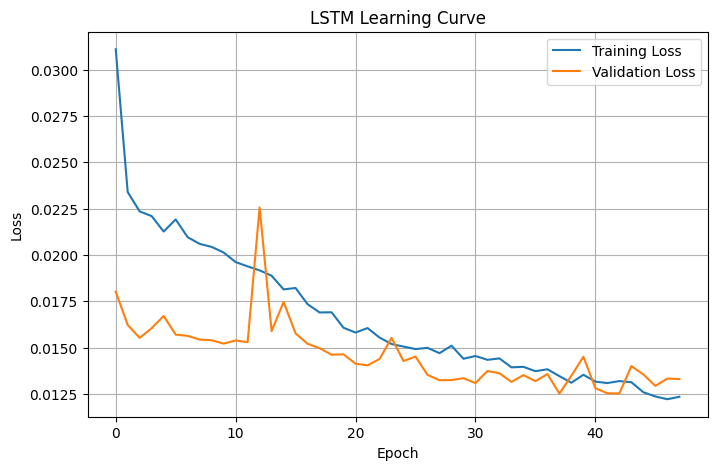

In [13]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()